# Training

In [4]:
import torch
import json, matplotlib.pyplot as plt

In [13]:
def load_log(path):
    with open(path) as f:
        return [json.loads(l) for l in f]

def split_runs(log):
    runs, current = [], []
    for entry in log:
        if current and entry["epoch"] <= current[-1]["epoch"]:
            runs.append(current)
            current = []
        current.append(entry)
    if current:
        runs.append(current)
    return runs

In [14]:
log    = load_log("models/training_log.jsonl")
runs   = split_runs(log)

In [15]:
print(f"Jumlah run: {len(runs)}")
for i, r in enumerate(runs):
    print(f"Run {i+1}: {len(r)} epochs, best F1={max(e['val_macro_f1'] for e in r):.4f}, gamma kemungkinan={'0.2' if i==0 else '0.5'}")

Jumlah run: 3
Run 1: 15 epochs, best F1=0.9618, gamma kemungkinan=0.2
Run 2: 15 epochs, best F1=0.9618, gamma kemungkinan=0.5
Run 3: 12 epochs, best F1=0.9603, gamma kemungkinan=0.5


In [9]:
# Lihat berapa run yang ada
runs = split_runs(load_log("models/training_log.jsonl"))
print(f"Jumlah run: {len(runs)}")
for i, r in enumerate(runs):
    print(f"Run {i+1}: {len(r)} epochs, best F1={max(e['val_macro_f1'] for e in r):.4f}")

Jumlah run: 3
Run 1: 15 epochs, best F1=0.9618
Run 2: 15 epochs, best F1=0.9618
Run 3: 12 epochs, best F1=0.9603


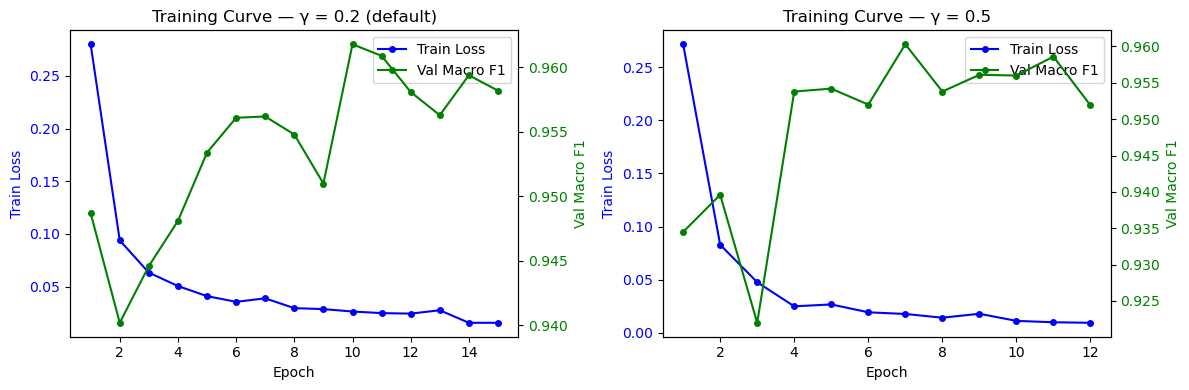

In [18]:
run_02 = runs[0]  # gamma=0.2, 15 epochs, F1=0.9618
run_05 = runs[2]  # gamma=0.5, 12 epochs, F1=0.9603

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, run, title in [
    (axes[0], run_02, "γ = 0.2 (default)"),
    (axes[1], run_05, "γ = 0.5"),
]:
    epochs = [r["epoch"] for r in run]
    losses = [r["train_loss"] for r in run]
    f1s    = [r["val_macro_f1"] for r in run]

    ax2 = ax.twinx()
    l1, = ax.plot(epochs, losses, "b-o", markersize=4, label="Train Loss")
    l2, = ax2.plot(epochs, f1s,   "g-o", markersize=4, label="Val Macro F1")

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Train Loss", color="blue")
    ax2.set_ylabel("Val Macro F1", color="green")
    ax.tick_params(axis="y", labelcolor="blue")
    ax2.tick_params(axis="y", labelcolor="green")
    ax.set_title(f"Training Curve — {title}")
    ax.legend(handles=[l1, l2], loc="upper right")

plt.tight_layout()
plt.savefig("results/training_curve_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Saliency

In [23]:
with open("results/saliency/saliency_scores.jsonl") as f:
    records = [json.loads(l) for l in f]

# Cari master_12018 dan master_10486
for rec in records:
    if rec["id"] in ["master_12018", "master_10486", "master_37925"]:
        print(f"\nID: {rec['id']}  violation: {rec['violation_id']}")
        tok_sal = list(zip(rec["tokens"], rec["saliency"]))
        # Sort by saliency
        ranked = sorted(tok_sal, key=lambda x: x[1], reverse=True)
        print("Top 10:")
        for rank, (tok, sal) in enumerate(ranked[:10], 1):
            print(f"  #{rank} {tok:<20} {sal:.4f}")


ID: master_12018  violation: V01
Top 10:
  #1 cent                 14.0855
  #2 <CLS>                7.6364
  #3 ratio                5.1309
  #4 :                    5.1234
  #5 5                    3.3005
  #6 påverkar             3.1912
  #7 illustrate           2.7706
  #8 value                2.4507
  #9 of                   2.0938
  #10 känslighetsanalys    1.9131


# Success Attack Flip

In [24]:
with open("results/attack/attack_results.jsonl") as f:
    results = [json.loads(l) for l in f]

for r in results:
    if r.get("attack_success"):
        print(f"ID: {r['id']}")
        print(f"Violation: {r['violation_id']}")
        print(f"Translation: {r['translation']}")
        print(f"Flip detail: {r['flip_detail']}")

ID: master_37925
Violation: V08
Translation: The profit from disposal of property is recognised as a realised change in value in profit or loss.
Flip detail: {'position': 25, 'original': 'change', 'synonym': 'movement', 'orig_prob': 0.9929, 'new_prob': 0.3499, 'saliency': 31.6181, 'flipped': True}


# Check test

In [1]:
import torch
ckpt = torch.load("models/best_model.pt", map_location="cpu", weights_only=False)
print("gamma:", ckpt["cfg"]["gamma"])
print("batch_size:", ckpt["cfg"]["batch_size"])
print("epoch:", ckpt["epoch"])
print("val_f1:", ckpt["val_macro_f1"])

gamma: 0.5
batch_size: 64
epoch: 7
val_f1: 0.9603061331377992


# Dump

In [3]:
ckpt = torch.load("models/best_model.pt", weights_only=False)
print(ckpt["epoch"])
print(ckpt["val_macro_f1"])
print(ckpt["cfg"])

7
0.9603061331377992
{'seed': 42, 'max_len': 256, 'vocab_size': 8000, 'd_model': 256, 'n_heads': 4, 'n_layers': 4, 'd_ff': 1024, 'dropout': 0.1, 'batch_size': 64, 'epochs': 20, 'lr': 0.0003, 'warmup_steps': 200, 'gamma': 0.5, 'w_compliant': 0.5911, 'w_violation': 3.2453, 'patience': 5}


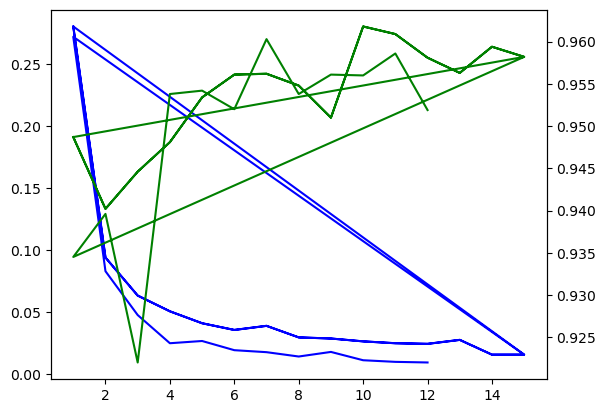

In [5]:
with open("models/training_log.jsonl") as f:
    log = [json.loads(l) for l in f]

epochs = [r["epoch"] for r in log]
f1s    = [r["val_macro_f1"] for r in log]
losses = [r["train_loss"] for r in log]

fig, ax1 = plt.subplots()
ax1.plot(epochs, losses, "b-", label="Train Loss")
ax2 = ax1.twinx()
ax2.plot(epochs, f1s, "g-", label="Val F1")
plt.savefig("results/training_curve.png")